
# 🧠 Lección: Embeddings de Palabras y el Modelo GloVe
### De la teoría a la práctica: entrenar, explorar y comparar embeddings

---

## Objetivos de aprendizaje

Al completar esta lección serás capaz de:

1. **Comprender** qué son los embeddings de palabras y por qué son útiles en NLP.
2. **Construir** una matriz de co-ocurrencias a partir de un corpus de texto.
3. **Entrenar** un modelo GloVe desde cero usando descenso de gradiente estocástico (SGD).
4. **Explorar** embeddings pre-entrenados (GloVe Wiki/Gigaword y Twitter).
5. **Visualizar** embeddings con t-SNE para descubrir agrupaciones semánticas.
6. **Comparar** embeddings propios vs. pre-entrenados mediante alineación (Procrustes ortogonal).

## Estructura

| Parte | Tema | Tiempo est. |
|-------|------|-------------|
| 1 | Fundamentos teóricos | 10 min |
| 2 | Entrenar GloVe desde cero (corpus español) | 20 min |
| 3 | Explorar embeddings pre-entrenados | 15 min |
| 4 | Efecto de hiperparámetros y cambio de dominio | 15 min |
| 5 | Comparar tu modelo vs. GloVe pre-entrenado | 20 min |
| 6 | Ejercicios propuestos | 10 min |

**Plataforma recomendada:** Google Colab (GPU no necesaria)
"""

In [ ]:
# %% [markdown]
"""
## Parte 0 · Instalación de dependencias

Ejecuta esta celda una sola vez para instalar los paquetes necesarios.
"""

# %%
!pip -q install numpy scipy scikit-learn matplotlib gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 96.7 MB/s eta 0:00:00


In [ ]:
# %%
import re
import math
import random
import numpy as np
from collections import defaultdict, Counter
from itertools import islice

import gensim.downloader as api
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

print("✅ Todas las dependencias cargadas correctamente.")

✅ Todas las dependencias cargadas correctamente.


---
## Parte 1 · Fundamentos Teóricos

### ¿Qué es un embedding de palabras?

Un **embedding** es una representación vectorial densa de una palabra.
Cada palabra se mapea a un vector de números reales (por ejemplo, de 50 o 100 dimensiones)
de tal forma que:

- Palabras con **significados similares** tienen vectores cercanos.
- **Relaciones semánticas** se capturan como direcciones en el espacio vectorial.

**Ejemplo clásico:**

$$\vec{\text{rey}} - \vec{\text{hombre}} + \vec{\text{mujer}} \approx \vec{\text{reina}}$$

Esto funciona porque los embeddings codifican **patrones de co-ocurrencia** del lenguaje:
palabras que aparecen en contextos similares terminan con representaciones similares.

### ¿Qué es GloVe?

**GloVe** (Global Vectors for Word Representation) fue propuesto por
Pennington et al. (2014) en Stanford. Su idea central tiene tres pasos:

**Paso 1 – Contar co-ocurrencias:** Para cada par de palabras $(i, j)$, contar cuántas
veces aparecen juntas dentro de una ventana de contexto. Esto produce la matriz $X_{ij}$.

**Paso 2 – Aprender vectores:** Encontrar vectores $W_i$ (palabra) y $C_j$ (contexto),
más sesgos $b_i$ y $b_j$, tales que:

$$W_i \cdot C_j + b_i + b_j \approx \log(X_{ij})$$

**Paso 3 – Ponderar la pérdida:** Usar una función de peso $f(X_{ij})$ para que
co-ocurrencias muy frecuentes no dominen el entrenamiento:

$$f(x) = \begin{cases} (x / x_{\max})^\alpha & \text{si } x < x_{\max} \\ 1 & \text{si } x \geq x_{\max} \end{cases}$$

La **función de pérdida** completa es:

$$J = \sum_{i,j} f(X_{ij}) \left( W_i \cdot C_j + b_i + b_j - \log X_{ij} \right)^2$$

> **Ventaja de GloVe:** combina información **global** (toda la matriz de co-ocurrencia)
> con un entrenamiento eficiente par-por-par, similar a Word2Vec.

In [ ]:

"""
---
## Parte 2 · Entrenar GloVe desde cero (corpus en español)

Usamos un corpus pequeño para que el entrenamiento sea rápido y podamos
inspeccionar cada paso con detalle. Más adelante (Parte 5) escalaremos a un corpus grande.

### 2.1 Corpus y Tokenización
"""

# %%
# ─── Corpus en español ───────────────────────────────────────────────
# Incluye oraciones sobre realeza, capitales, banca y animales
# para observar cómo GloVe agrupa palabras por temática.

corpus = [
    "el rey ama a la reina",
    "la reina ama al rey",
    "el rey gobierna el reino",
    "la reina gobierna el reino",
    "el príncipe es el hijo del rey",
    "la princesa es la hija de la reina",
    "parís es la capital de francia",
    "berlín es la capital de alemania",
    "roma es la capital de italia",
    "madrid es la capital de españa",
    "el dinero está en el banco",
    "deposité dinero en el banco",
    "el banco aprobó el préstamo",
    "trabajo en un banco grande",
    "me senté en un banco del parque",
    "el banco de la plaza es de madera",
    "el banco del parque estaba mojado",
    "los perros y los gatos son animales",
    "un perro es un animal leal",
    "un gato es un animal curioso",
]

# ─── Tokenizador simple ─────────────────────────────────────────────
# Usa una expresión regular que mantiene tildes y ñ.
TOKEN_RE = re.compile(r"[a-záéíóúüñ]+", flags=re.IGNORECASE)

def tokenize(texto):
    """Devuelve lista de tokens en minúsculas."""
    return TOKEN_RE.findall(texto.lower())

oraciones = [tokenize(s) for s in corpus]

# Veamos cómo funciona:
print("Ejemplo de tokenización:")
print(f"  Texto:   '{corpus[0]}'")
print(f"  Tokens:  {oraciones[0]}")
print(f"\nTotal de oraciones: {len(oraciones)}")

Ejemplo de tokenización:
  Texto:   'el rey ama a la reina'
  Tokens:  ['el', 'rey', 'ama', 'a', 'la', 'reina']

Total de oraciones: 20


In [ ]:
"""
### 2.2 Construcción del Vocabulario

Creamos dos diccionarios:
- `stoi` (**s**tring **to** **i**nteger): mapea cada palabra a un índice numérico.
- `itos` (**i**nteger **to** **s**tring): mapea cada índice de vuelta a la palabra.

Esto nos permite trabajar con matrices numéricas eficientemente.
"""

# %%
vocab_es = sorted({w for sent in oraciones for w in sent})
stoi_es  = {w: i for i, w in enumerate(vocab_es)}
itos_es  = {i: w for i, w in enumerate(vocab_es)}
V_es     = len(vocab_es)

print(f"Tamaño del vocabulario: {V_es}")
print(f"Primeras 15 palabras: {vocab_es[:15]}")
print(f"\nEjemplo stoi: 'rey' → {stoi_es.get('rey', '??')}")
print(f"Ejemplo itos: {stoi_es.get('rey', '??')} → '{itos_es.get(stoi_es.get('rey', 0), '??')}'")

Tamaño del vocabulario: 53
Primeras 15 palabras: ['a', 'al', 'alemania', 'ama', 'animal', 'animales', 'aprobó', 'banco', 'berlín', 'capital', 'curioso', 'de', 'del', 'deposité', 'dinero']

Ejemplo stoi: 'rey' → 46
Ejemplo itos: 46 → 'rey'


In [ ]:

"""
### 2.3 Matriz de Co-ocurrencias

La co-ocurrencia mide cuántas veces dos palabras aparecen juntas dentro
de una **ventana de contexto**.

Usamos **ponderación por distancia**: palabras más cercanas al centro
contribuyen más al conteo.

**Ejemplo con ventana = 2 y la oración** *"el rey ama a la reina"*:

Centro en "ama" (posición 2):
| Posición | Palabra | Distancia | Aporte |
|----------|---------|-----------|--------|
| 1 | "rey" | 1 | 1/1 = 1.0 |
| 0 | "el" | 2 | 1/2 = 0.5 |
| 3 | "a" | 1 | 1/1 = 1.0 |
| 4 | "la" | 2 | 1/2 = 0.5 |
"""

# %%
VENTANA = 4
cooc_es = defaultdict(float)

for sent in oraciones:
    ids = [stoi_es[w] for w in sent]
    for centro, wi in enumerate(ids):
        inicio = max(0, centro - VENTANA)
        fin    = min(len(ids), centro + VENTANA + 1)
        for ctx_pos in range(inicio, fin):
            if ctx_pos == centro:
                continue
            wj = ids[ctx_pos]
            dist = abs(ctx_pos - centro)
            cooc_es[(wi, wj)] += 1.0 / dist  # más cercana → más peso

cooc_items_es = list(cooc_es.items())

print(f"Pares de co-ocurrencia: {len(cooc_items_es)}")

# Veamos los 5 pares con mayor co-ocurrencia
top_pares = sorted(cooc_es.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 pares con mayor co-ocurrencia:")
for (i, j), val in top_pares:
    print(f"  ({itos_es[i]:>10s}, {itos_es[j]:<10s}) → {val:.2f}")

Pares de co-ocurrencia: 373

Top 5 pares con mayor co-ocurrencia:
  (        la, es        ) → 6.25
  (        es, la        ) → 6.25
  (        el, banco     ) → 5.50
  (     banco, el        ) → 5.50
  (        la, de        ) → 4.83


In [ ]:

"""
### 2.4 Entrenamiento de GloVe con SGD

Ahora implementamos el algoritmo GloVe paso a paso:

1. **Inicialización aleatoria** de matrices de vectores $W$ (palabra) y $C$ (contexto), más sesgos $b_W$ y $b_C$.
2. **Para cada época**, iteramos sobre todos los pares de co-ocurrencia y actualizamos los parámetros minimizando la pérdida ponderada.

La actualización de cada par $(i, j)$ con co-ocurrencia $x$ es:

$$\\text{grad} = 2 \\cdot f(x) \\cdot \\left( W_i \\cdot C_j + b_i + b_j - \\log(x) \\right)$$

$$W_i \\leftarrow W_i - \\eta \\cdot \\text{grad} \\cdot C_j$$
$$C_j \\leftarrow C_j - \\eta \\cdot \\text{grad} \\cdot W_i$$
$$b_i \\leftarrow b_i - \\eta \\cdot \\text{grad}$$
$$b_j \\leftarrow b_j - \\eta \\cdot \\text{grad}$$
"""

# %%
# ─── Hiperparámetros ─────────────────────────────────────────────────
np.random.seed(0)
random.seed(0)

DIM_ES   = 30      # dimensión de los embeddings (pequeña para este corpus)
LR_ES    = 0.05    # tasa de aprendizaje
EPOCHS_ES = 40     # épocas de entrenamiento
X_MAX_ES  = 10.0   # umbral para la función de peso
ALPHA_ES  = 0.75   # exponente de la función de peso

# ─── Inicialización de parámetros ────────────────────────────────────
W_es  = np.random.normal(0, 0.1, size=(V_es, DIM_ES))   # vectores de palabra
C_es  = np.random.normal(0, 0.1, size=(V_es, DIM_ES))   # vectores de contexto
bW_es = np.zeros(V_es)                                    # sesgos de palabra
bC_es = np.zeros(V_es)                                    # sesgos de contexto

def peso_glove(x, x_max=X_MAX_ES, alpha=ALPHA_ES):
    """
    Función de peso de GloVe:
      f(x) = (x / x_max)^α  si x < x_max
      f(x) = 1               si x ≥ x_max

    Esto evita que pares muy frecuentes (como 'el', 'de')
    dominen completamente el entrenamiento.
    """
    return 1.0 if x >= x_max else (x / x_max) ** alpha

# ─── Bucle de entrenamiento ──────────────────────────────────────────
print("Entrenando GloVe (SGD) sobre corpus en español...\n")
perdidas = []

for epoca in range(EPOCHS_ES):
    random.shuffle(cooc_items_es)
    perdida_total = 0.0

    for (i, j), x in cooc_items_es:
        w = peso_glove(x)

        # Predicción: W_i · C_j + b_i + b_j
        pred = W_es[i].dot(C_es[j]) + bW_es[i] + bC_es[j]
        diff = pred - math.log(x)

        perdida_total += w * diff * diff

        # Gradiente y actualización SGD
        grad = 2.0 * w * diff

        wi_copia = W_es[i].copy()       # guardamos copia ANTES de actualizar
        W_es[i]  -= LR_ES * grad * C_es[j]
        C_es[j]  -= LR_ES * grad * wi_copia
        bW_es[i] -= LR_ES * grad
        bC_es[j] -= LR_ES * grad

    avg_loss = perdida_total / len(cooc_items_es)
    perdidas.append(avg_loss)

    if (epoca + 1) % 10 == 0:
        print(f"  Época {epoca+1:3d} | Pérdida promedio: {avg_loss:.4f}")

print("\n✅ Entrenamiento completado.")

Entrenando GloVe (SGD) sobre corpus en español...

  Época  10 | Pérdida promedio: 0.0548
  Época  20 | Pérdida promedio: 0.0282
  Época  30 | Pérdida promedio: 0.0172
  Época  40 | Pérdida promedio: 0.0105

✅ Entrenamiento completado.


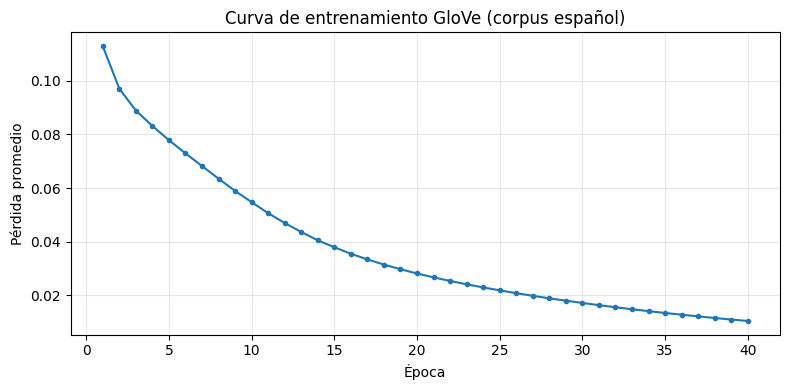

Forma del embedding: (53, 30)  (vocabulario × dimensión)
Norma del vector 'rey': 1.0000 (≈ 1.0 tras normalizar)


In [ ]:

"""
### 2.5 Curva de pérdida y embedding final

Grafiquemos la pérdida para verificar que el modelo convergió.

El **embedding final** se obtiene sumando los vectores de palabra y contexto:
$E = W + C$, y luego normalizándolos a norma unitaria para facilitar
el cálculo de similitud coseno.
"""

# %%
# ─── Gráfica de la pérdida ───────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS_ES + 1), perdidas, marker='o', markersize=3)
plt.xlabel("Época")
plt.ylabel("Pérdida promedio")
plt.title("Curva de entrenamiento GloVe (corpus español)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ─── Embedding final: E = W + C, normalizado ────────────────────────
E_es = W_es + C_es
E_es = E_es / (np.linalg.norm(E_es, axis=1, keepdims=True) + 1e-8)

print(f"Forma del embedding: {E_es.shape}  (vocabulario × dimensión)")
print(f"Norma del vector 'rey': {np.linalg.norm(E_es[stoi_es['rey']]):.4f} (≈ 1.0 tras normalizar)")

In [ ]:

"""
### 2.6 Consultar similitudes en nuestro modelo entrenado

Definimos una función que, dada una palabra, encuentra las más similares
usando **similitud coseno**:

$$\\text{coseno}(u, v) = \\frac{u \\cdot v}{\\|u\\| \\, \\|v\\|}$$

Como los vectores ya están normalizados, esto se simplifica a un producto punto.
"""

# %%
def similares_es(palabra, topn=8):
    """Encuentra las palabras más similares en nuestro modelo entrenado."""
    if palabra not in stoi_es:
        print(f"  ⚠️  '{palabra}' no está en el vocabulario.")
        return

    idx = stoi_es[palabra]
    query = E_es[idx]

    # Como E_es está normalizado, el producto punto = similitud coseno
    similitudes = E_es @ query
    mejores = np.argsort(-similitudes)

    resultado = []
    for j in mejores:
        if j == idx:
            continue
        resultado.append((itos_es[j], float(similitudes[j])))
        if len(resultado) == topn:
            break

    for pal, sim in resultado:
        print(f"  {pal:15s} {sim:.4f}")

# ─── Probemos con varias palabras ────────────────────────────────────
consultas = ["rey", "reina", "banco", "dinero", "capital", "españa", "perro", "gato"]

for w in consultas:
    print(f"\n{'='*50}")
    print(f"Palabra: {w}")
    similares_es(w, topn=6)


Palabra: rey
  el              0.6684
  al              0.6106
  gobierna        0.6100
  madera          0.5981
  leal            0.5850
  banco           0.5843

Palabra: reina
  la              0.7672
  es              0.7237
  plaza           0.6199
  capital         0.4931
  gato            0.4479
  perro           0.4412

Palabra: banco
  el              0.8222
  gobierna        0.5963
  rey             0.5843
  en              0.5076
  leal            0.4843
  del             0.4713

Palabra: dinero
  roma            0.3930
  me              0.3445
  deposité        0.3264
  hija            0.3184
  al              0.2734
  mojado          0.2728

Palabra: capital
  de              0.9638
  la              0.8681
  es              0.7285
  plaza           0.6901
  reina           0.4931
  hija            0.4443

Palabra: españa
  italia          0.6299
  francia         0.5030
  leal            0.4719
  grande          0.4671
  madera          0.4471
  reino           0.4230

P

In [ ]:
"""
---
## Parte 3 · Explorar Embeddings Pre-entrenados

Los modelos pre-entrenados de GloVe fueron entrenados sobre **miles de millones
de palabras** (Wikipedia + Gigaword). Esto les da una comprensión semántica
mucho más rica que nuestro corpus de 20 oraciones.

Usamos la librería `gensim` para cargar estos modelos fácilmente.

> ⏳ **Nota:** La primera vez que ejecutes esta celda, se descargará
> el modelo (~128 MB). Las siguientes veces se usará la caché local.
"""

# %%
print("Cargando GloVe pre-entrenado (Wiki/Gigaword, 100 dimensiones)...")
wv = api.load("glove-wiki-gigaword-100")
print(f"✅ Cargado. Vocabulario: {len(wv):,} palabras")

# ─── Vecinos más cercanos ────────────────────────────────────────────
palabras_prueba = ["apple", "bank", "python", "jaguar", "doctor", "sad", "music"]

for w in palabras_prueba:
    print(f"\n{'='*50}")
    print(f"Palabra: {w}")
    if w in wv:
        for vecino, sim in wv.most_similar(w, topn=8):
            print(f"  {vecino:15s} {sim:.3f}")
    else:
        print("  (no está en el vocabulario)")

Cargando GloVe pre-entrenado (Wiki/Gigaword, 100 dimensiones)...
[==================================================] 100.0% 128.1/128.1MB downloaded
✅ Cargado. Vocabulario: 400,000 palabras

Palabra: apple
  microsoft       0.745
  ibm             0.682
  intel           0.678
  software        0.678
  dell            0.674
  pc              0.668
  macintosh       0.662
  iphone          0.660

Palabra: bank
  banks           0.806
  banking         0.753
  credit          0.704
  investment      0.694
  financial       0.678
  securities      0.669
  lending         0.665
  funds           0.648

Palabra: python
  monty           0.689
  php             0.587
  perl            0.578
  cleese          0.545
  flipper         0.511
  ruby            0.507
  spamalot        0.506
  javascript      0.503

Palabra: jaguar
  rover           0.749
  mustang         0.666
  cadillac        0.618
  taurus          0.605
  subaru          0.599
  bmw             0.593
  falcon          0.589


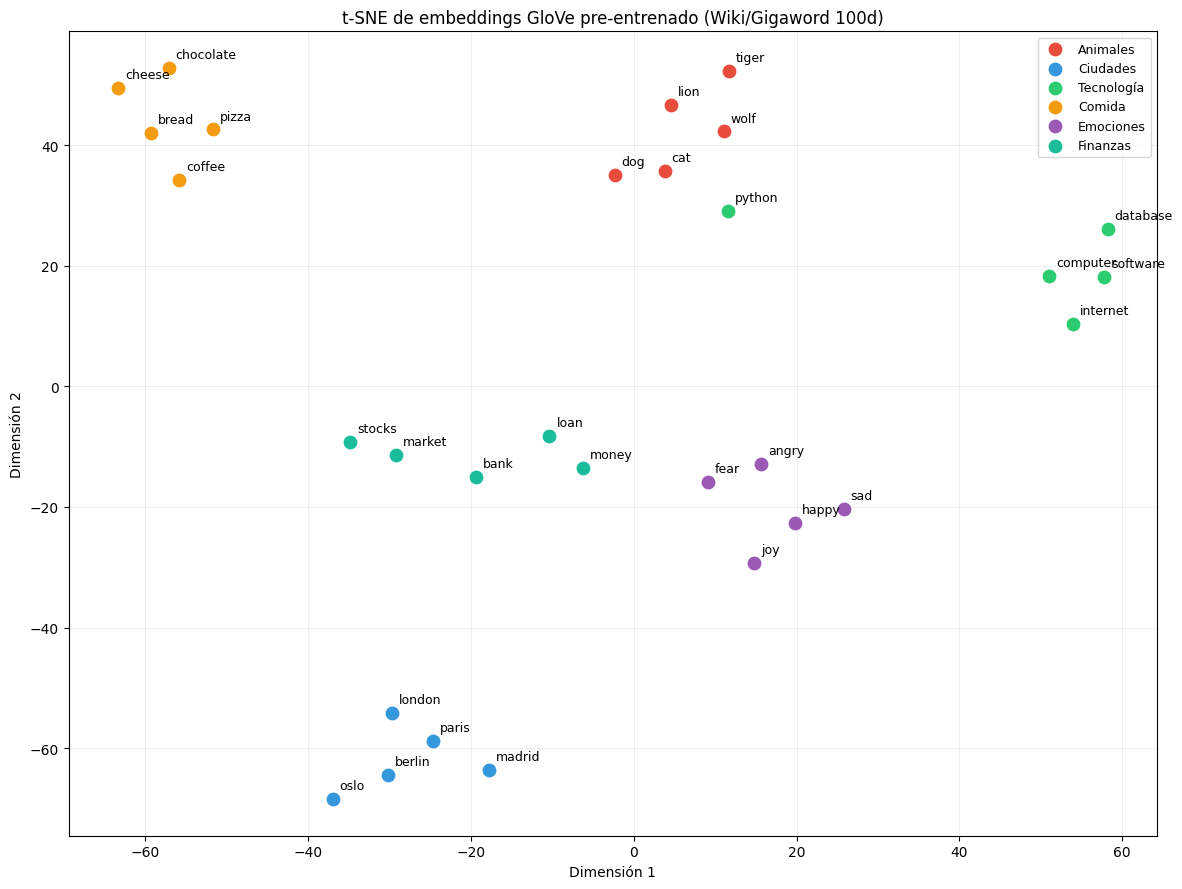

In [ ]:
"""
### 3.1 Visualización con t-SNE

**t-SNE** (t-distributed Stochastic Neighbor Embedding) reduce los vectores
de 100 dimensiones a 2 dimensiones para poder visualizarlos.

Lo poderoso es que **preserva las relaciones de vecindad**: palabras que están
cerca en 100D tienden a estar cerca en 2D.

Seleccionamos palabras de distintas categorías semánticas para ver si
GloVe las agrupa correctamente:
- 🐾 Animales: cat, dog, wolf, tiger, lion
- 🏙️ Ciudades: paris, london, berlin, oslo, madrid
- 💻 Tecnología: computer, software, internet, python, database
- 🍕 Comida: pizza, bread, cheese, chocolate, coffee
- 😊 Emociones: happy, sad, angry, fear, joy
- 💰 Finanzas: bank, money, loan, stocks, market
"""

# %%
palabras_tsne = [
    "cat", "dog", "wolf", "tiger", "lion",
    "paris", "london", "berlin", "oslo", "madrid",
    "computer", "software", "internet", "python", "database",
    "pizza", "bread", "cheese", "chocolate", "coffee",
    "happy", "sad", "angry", "fear", "joy",
    "bank", "money", "loan", "stocks", "market",
]

# Filtrar las que existen en el vocabulario
kept = [w for w in palabras_tsne if w in wv]
X_tsne = np.array([wv[w] for w in kept])

# Aplicar t-SNE
Y_tsne = TSNE(
    n_components=2,
    perplexity=5,
    random_state=0,
    init="pca"
).fit_transform(X_tsne)

# ─── Gráfica ─────────────────────────────────────────────────────────
# Asignamos colores por categoría
categorias = {
    "Animales":   ["cat", "dog", "wolf", "tiger", "lion"],
    "Ciudades":   ["paris", "london", "berlin", "oslo", "madrid"],
    "Tecnología": ["computer", "software", "internet", "python", "database"],
    "Comida":     ["pizza", "bread", "cheese", "chocolate", "coffee"],
    "Emociones":  ["happy", "sad", "angry", "fear", "joy"],
    "Finanzas":   ["bank", "money", "loan", "stocks", "market"],
}
colores_cat = {
    "Animales": "#e74c3c", "Ciudades": "#3498db", "Tecnología": "#2ecc71",
    "Comida": "#f39c12",   "Emociones": "#9b59b6", "Finanzas": "#1abc9c",
}

def categoria_de(palabra):
    for cat, words in categorias.items():
        if palabra in words:
            return cat
    return "Otro"

plt.figure(figsize=(12, 9))

# Dibujar puntos coloreados por categoría
for cat, color in colores_cat.items():
    indices = [i for i, w in enumerate(kept) if categoria_de(w) == cat]
    if indices:
        plt.scatter(
            Y_tsne[indices, 0], Y_tsne[indices, 1],
            c=color, label=cat, s=80, zorder=3
        )

# Etiquetas de texto
for i, w in enumerate(kept):
    plt.annotate(
        w, (Y_tsne[i, 0], Y_tsne[i, 1]),
        fontsize=9, ha='left', va='bottom',
        xytext=(5, 5), textcoords='offset points'
    )

plt.title("t-SNE de embeddings GloVe pre-entrenado (Wiki/Gigaword 100d)")
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")
plt.legend(loc="best", fontsize=9)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
"""
---
## Parte 4 · Efecto de Hiperparámetros y Cambio de Dominio

### 4.1 Cambio de dominio: Wikipedia vs. Twitter

Los embeddings reflejan el **corpus donde fueron entrenados**. Una misma
palabra puede tener vecinos muy diferentes según el dominio:

- **Wikipedia/Gigaword**: texto formal, enciclopédico, periodístico.
- **Twitter**: texto informal, coloquial, con jerga de internet.

Esto se conoce como **domain shift** (cambio de dominio) y es un fenómeno
fundamental que hay que considerar al usar embeddings pre-entrenados.

> ⏳ La primera carga de `glove-twitter-100` descarga ~200 MB.
"""

# %%
print("Cargando GloVe Twitter (100d)...")
tw = api.load("glove-twitter-100")
print(f"✅ Cargado. Vocabulario Twitter: {len(tw):,} palabras")

# Reutilizamos 'wv' como wiki (ya cargado en la celda anterior)
wiki_dm = wv  # renombramos para claridad

palabras_dominio = ["virus", "cloud", "java", "python", "apple", "bank", "model", "screen"]

for w in palabras_dominio:
    print(f"\n{'='*60}")
    print(f"Palabra: {w}")

    print("\n  📚 Wiki/Gigaword:")
    if w in wiki_dm:
        for t, s in wiki_dm.most_similar(w, topn=6):
            print(f"    {t:15s} {s:.3f}")
    else:
        print("    (fuera de vocabulario)")

    print("\n  🐦 Twitter:")
    if w in tw:
        for t, s in tw.most_similar(w, topn=6):
            print(f"    {t:15s} {s:.3f}")
    else:
        print("    (fuera de vocabulario)")

Cargando GloVe Twitter (100d)...
[==================================================] 100.0% 387.1/387.1MB downloaded
✅ Cargado. Vocabulario Twitter: 1,193,514 palabras

Palabra: virus

  📚 Wiki/Gigaword:
    flu             0.840
    influenza       0.819
    h5n1            0.813
    viruses         0.796
    infected        0.792
    infection       0.786

  🐦 Twitter:
    malware         0.688
    hepatitis       0.647
    influenza       0.631
    flu             0.610
    anti            0.609
    hiv             0.603

Palabra: cloud

  📚 Wiki/Gigaword:
    clouds          0.767
    ash             0.712
    dust            0.664
    sky             0.620
    mist            0.615
    fog             0.602

  🐦 Twitter:
    enterprise      0.730
    computing       0.706
    windows         0.689
    mobile          0.676
    technology      0.669
    tech            0.669

Palabra: java

  📚 Wiki/Gigaword:
    sumatra         0.664
    surabaya        0.660
    semarang        

In [ ]:
"""
### 4.2 Efecto de la dimensión del embedding

¿Importa si usamos 50, 100 o 200 dimensiones? ¡Sí!

- **Pocas dimensiones** (50d): más rápido, pero pierde matices semánticos.
- **Muchas dimensiones** (200d): captura relaciones más finas, pero requiere más datos y es más lento.

Comparemos los vecinos de varias palabras usando GloVe con distintas dimensiones.

> ⏳ Se descargan 3 modelos (~66 MB + 128 MB + 252 MB).
"""

# %%
print("Cargando modelos GloVe de distintas dimensiones...")
g50  = api.load("glove-wiki-gigaword-50")
g100 = wv  # ya lo tenemos cargado
g200 = api.load("glove-wiki-gigaword-200")
print("✅ Los 3 modelos están cargados.")

modelos = [
    ("GloVe  50d", g50),
    ("GloVe 100d", g100),
    ("GloVe 200d", g200),
]

palabras_dim = ["king", "queen", "bank", "computer", "river", "money"]

for w in palabras_dim:
    print(f"\n{'='*70}")
    print(f"Palabra: {w}")

    for nombre, modelo in modelos:
        print(f"\n  {nombre}:")
        if w in modelo:
            for t, s in modelo.most_similar(w, topn=5):
                print(f"    {t:15s} {s:.3f}")
        else:
            print("    (fuera de vocabulario)")

Cargando modelos GloVe de distintas dimensiones...
[==================================================] 100.0% 66.0/66.0MB downloaded
[==================================================] 100.0% 252.1/252.1MB downloaded
✅ Los 3 modelos están cargados.

Palabra: king

  GloVe  50d:
    prince          0.824
    queen           0.784
    ii              0.775
    emperor         0.774
    son             0.767

  GloVe 100d:
    prince          0.768
    queen           0.751
    son             0.702
    brother         0.699
    monarch         0.698

  GloVe 200d:
    prince          0.685
    queen           0.667
    kingdom         0.630
    monarch         0.622
    ii              0.615

Palabra: queen

  GloVe  50d:
    princess        0.852
    lady            0.805
    elizabeth       0.787
    king            0.784
    prince          0.782

  GloVe 100d:
    princess        0.795
    king            0.751
    elizabeth       0.736
    royal           0.707
    lady           

In [ ]:
"""
---
## Parte 5 · Comparar tu Modelo vs. GloVe Pre-entrenado

Ahora viene lo más interesante: **entrenaremos GloVe sobre un corpus real
en inglés** (text8, derivado de Wikipedia) y compararemos los vectores
resultantes contra los vectores pre-entrenados oficiales.

### 5.1 Entrenar GloVe sobre el corpus text8

Usamos los mismos pasos que en la Parte 2, pero con un corpus mucho más grande.

> ⚠️ **Esta celda tarda ~5-10 minutos.** Puedes reducir `N_SENTENCES` o `EPOCHS`
> si deseas resultados más rápidos (a costa de menor calidad).
"""

# %%
# ─── Cargar corpus text8 ─────────────────────────────────────────────
N_SENTENCES = 30_000     # oraciones del corpus text8
MAX_VOCAB   = 10_000     # palabras más frecuentes a conservar
MIN_COUNT   = 5          # ignorar palabras con menos apariciones

print(f"Cargando corpus text8 (primeras {N_SENTENCES:,} oraciones)...")
raw_sentences = list(islice(api.load("text8"), N_SENTENCES))

# Construir vocabulario por frecuencia
counts = Counter()
for s in raw_sentences:
    counts.update(s)

vocab_en = [w for (w, c) in counts.most_common(MAX_VOCAB) if c >= MIN_COUNT]
stoi_en  = {w: i for i, w in enumerate(vocab_en)}
itos_en  = {i: w for w, i in stoi_en.items()}
V_en     = len(vocab_en)

print(f"Vocabulario: {V_en:,} palabras")
print(f"Ejemplo: {vocab_en[:15]}")

# ─── Co-ocurrencias ──────────────────────────────────────────────────
print("\nCalculando co-ocurrencias...")
WINDOW_EN = 4
cooc_en = defaultdict(float)

for sent in raw_sentences:
    ids = [stoi_en[w] for w in sent if w in stoi_en]
    for centro, wi in enumerate(ids):
        inicio = max(0, centro - WINDOW_EN)
        fin    = min(len(ids), centro + WINDOW_EN + 1)
        for ctx_pos in range(inicio, fin):
            if ctx_pos == centro:
                continue
            wj = ids[ctx_pos]
            dist = abs(ctx_pos - centro)
            cooc_en[(wi, wj)] += 1.0 / dist

cooc_items_en = list(cooc_en.items())
print(f"Pares de co-ocurrencia: {len(cooc_items_en):,}")

# ─── Entrenamiento GloVe ─────────────────────────────────────────────
np.random.seed(0)
random.seed(0)

DIM_EN    = 100     # ¡Importante! Misma dimensión que GloVe pre-entrenado
LR_EN     = 0.05
EPOCHS_EN = 8
X_MAX_EN  = 10.0
ALPHA_EN  = 0.75

W_en  = np.random.normal(0, 0.1, size=(V_en, DIM_EN))
C_en  = np.random.normal(0, 0.1, size=(V_en, DIM_EN))
bW_en = np.zeros(V_en)
bC_en = np.zeros(V_en)

def peso_en(x):
    return 1.0 if x >= X_MAX_EN else (x / X_MAX_EN) ** ALPHA_EN

print(f"\nEntrenando GloVe ({EPOCHS_EN} épocas, dim={DIM_EN})...")
for epoca in range(EPOCHS_EN):
    random.shuffle(cooc_items_en)
    perdida_total = 0.0

    for (i, j), x in cooc_items_en:
        w = peso_en(x)
        pred = W_en[i].dot(C_en[j]) + bW_en[i] + bC_en[j]
        diff = pred - math.log(x)
        perdida_total += w * diff * diff

        grad = 2.0 * w * diff
        wi_old = W_en[i].copy()
        W_en[i]  -= LR_EN * grad * C_en[j]
        C_en[j]  -= LR_EN * grad * wi_old
        bW_en[i] -= LR_EN * grad
        bC_en[j] -= LR_EN * grad

    print(f"  Época {epoca+1:02d} | Pérdida promedio: {perdida_total / len(cooc_items_en):.4f}")

# Embedding final
E_en = W_en + C_en
E_en = E_en / (np.linalg.norm(E_en, axis=1, keepdims=True) + 1e-9)

print("\n✅ Entrenamiento completado.")
print(f"Forma del embedding: {E_en.shape}")

Cargando corpus text8 (primeras 30,000 oraciones)...
[==================================================] 100.0% 31.6/31.6MB downloaded
Vocabulario: 10,000 palabras
Ejemplo: ['the', 'of', 'and', 'one', 'in', 'a', 'to', 'zero', 'nine', 'two', 'is', 'as', 'eight', 'for', 's']

Calculando co-ocurrencias...
Pares de co-ocurrencia: 12,806,546

Entrenando GloVe (8 épocas, dim=100)...
  Época 01 | Pérdida promedio: 0.1910
  Época 02 | Pérdida promedio: 0.1448
  Época 03 | Pérdida promedio: 0.1319


In [ ]:
"""
### 5.2 Alineación con Procrustes Ortogonal

Un problema fundamental: **dos entrenamientos independientes producen
espacios vectoriales rotados de forma diferente**. La palabra "king" puede
tener un vector completamente distinto en cada modelo, aunque capture la
misma semántica.

Para poder comparar ambos modelos en el mismo gráfico, necesitamos
**alinear** un espacio con el otro.

**Procrustes Ortogonal** encuentra la matriz de rotación $R$ que minimiza:

$$\\min_R \\| X R - Y \\|_F^2 \\quad \\text{sujeto a } R^T R = I$$

donde $X$ son nuestros vectores entrenados e $Y$ los pre-entrenados, para
un conjunto de **palabras ancla** compartidas.

La solución se obtiene mediante SVD:

$$M = X^T Y, \\quad M = U \\Sigma V^T, \\quad R = U V^T$$
"""

# %%
# ─── Cargar GloVe pre-entrenado (Wiki/Gigaword 100d) ────────────────
# Si ya lo cargaste antes, reutilizamos 'wv'. Si no, descomenta:
# wv = api.load("glove-wiki-gigaword-100")
wiki = wv  # referencia al modelo pre-entrenado

# ─── Encontrar palabras compartidas (anclas) ─────────────────────────
N_ANCHORS = 5_000
compartidas = [w for w in vocab_en if w in wiki][:N_ANCHORS]
print(f"Palabras ancla compartidas: {len(compartidas):,}")

# ─── Construir matrices para alineación ──────────────────────────────
X_align = np.vstack([E_en[stoi_en[w]] for w in compartidas])                    # nuestro modelo
Y_align = np.vstack([wiki.get_vector(w, norm=True) for w in compartidas])  # pre-entrenado

# ─── SVD → Matriz de rotación R ──────────────────────────────────────
M = X_align.T @ Y_align
U, sigma, Vt = np.linalg.svd(M)
R = U @ Vt

print(f"Matriz de rotación R: {R.shape}")
print(f"Verificación R^T R ≈ I: error = {np.linalg.norm(R.T @ R - np.eye(DIM_EN)):.2e}")

def vec_alineado(palabra):
    """Retorna el vector entrenado, rotado al espacio del modelo pre-entrenado."""
    v = E_en[stoi_en[palabra]] @ R
    return v / (np.linalg.norm(v) + 1e-9)

print("\n✅ Alineación completada. Ambos modelos están ahora en el mismo espacio vectorial.")

In [ ]:
"""
### 5.3 Comparar vecinos: modelo propio vs. pre-entrenado

Ahora podemos comparar, palabra por palabra, qué vecinos encuentra cada modelo.

Observa las diferencias: el modelo pre-entrenado (entrenado con **6 mil millones**
de tokens) debería tener vecinos más precisos y diversos que nuestro modelo
(entrenado con solo una fracción del corpus).
"""

# %%
def similares_entrenado(palabra, topn=8):
    """Vecinos más cercanos en nuestro modelo entrenado."""
    if palabra not in stoi_en:
        print("  (fuera de vocabulario en modelo entrenado)")
        return
    q = E_en[stoi_en[palabra]]
    sims = E_en @ q
    best = np.argsort(-sims)
    resultado = []
    for idx in best:
        if itos_en[idx] == palabra:
            continue
        resultado.append((itos_en[idx], float(sims[idx])))
        if len(resultado) == topn:
            break
    for t, s in resultado:
        print(f"    {t:15s} {s:.3f}")

# ─── Palabras de prueba ──────────────────────────────────────────────
probe_words = ["king", "queen", "bank", "money", "computer", "python", "paris", "music"]
probe_words = [w for w in probe_words if (w in wiki and w in stoi_en)]

for w in probe_words:
    print(f"\n{'='*60}")
    print(f"Palabra: {w}")

    print("\n  📚 GloVe Pre-entrenado (Wiki/Gigaword):")
    for t, s in wiki.most_similar(w, topn=6):
        print(f"    {t:15s} {s:.3f}")

    print(f"\n  🔧 GloVe Entrenado por nosotros (text8):")
    similares_entrenado(w, topn=6)

In [ ]:
"""
### 5.4 Visualización t-SNE: ambos modelos en el mismo espacio

Gracias a la alineación de Procrustes, podemos proyectar ambos modelos
en un mismo gráfico t-SNE.

Cada palabra aparece **dos veces**:
- ⚪ Círculo: vector del modelo **pre-entrenado** (Wiki/Gigaword)
- ✕ Cruz: vector de **nuestro modelo** (alineado)

Las **líneas** conectan la misma palabra en ambos modelos.
Si la línea es corta, ambos modelos coinciden bien para esa palabra.
"""

# %%
palabras_plot = [
    "cat", "dog", "wolf", "tiger", "lion",
    "paris", "london", "berlin", "oslo", "madrid",
    "computer", "software", "internet", "python", "database",
    "pizza", "bread", "cheese", "chocolate", "coffee",
    "happy", "sad", "angry", "fear", "joy",
    "bank", "money", "loan", "stocks", "market",
]

# Solo palabras que existan en AMBOS modelos
kept_comp = [w for w in palabras_plot if (w in wiki and w in stoi_en)]
print(f"Palabras a graficar: {len(kept_comp)}")

# Construir vectores intercalados: [wiki_w1, trained_w1, wiki_w2, trained_w2, ...]
vecs_comp = []
labels_comp = []
tag_comp = []  # 0 = pre-entrenado, 1 = entrenado

for w in kept_comp:
    vecs_comp.append(wiki.get_vector(w, norm=True))
    labels_comp.append(f"{w} (wiki)")
    tag_comp.append(0)

    vecs_comp.append(vec_alineado(w))
    labels_comp.append(f"{w} (propio)")
    tag_comp.append(1)

vecs_comp = np.array(vecs_comp)
tag_comp  = np.array(tag_comp)

# ─── t-SNE ───────────────────────────────────────────────────────────
perplexity = min(10, max(2, (len(vecs_comp) - 1) // 3))
Y_comp = TSNE(
    n_components=2,
    perplexity=perplexity,
    random_state=0,
    init="pca",
    learning_rate="auto",
).fit_transform(vecs_comp)

# ─── Gráfica ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 10))

idx_wiki = np.where(tag_comp == 0)[0]
idx_own  = np.where(tag_comp == 1)[0]

ax.scatter(Y_comp[idx_wiki, 0], Y_comp[idx_wiki, 1],
           marker="o", s=60, c="#3498db", label="GloVe Pre-entrenado (Wiki)", zorder=3)
ax.scatter(Y_comp[idx_own, 0],  Y_comp[idx_own, 1],
           marker="x", s=60, c="#e74c3c", label="GloVe Entrenado (alineado)", zorder=3)

# Líneas conectando wiki ↔ entrenado para la misma palabra
for k, w in enumerate(kept_comp):
    i_w = 2 * k      # índice wiki
    i_t = 2 * k + 1  # índice trained
    ax.plot(
        [Y_comp[i_w, 0], Y_comp[i_t, 0]],
        [Y_comp[i_w, 1], Y_comp[i_t, 1]],
        color="gray", linewidth=0.6, alpha=0.5
    )

# Etiquetas (solo para wiki, para no saturar)
for k, w in enumerate(kept_comp):
    i_w = 2 * k
    ax.annotate(w, (Y_comp[i_w, 0], Y_comp[i_w, 1]),
                fontsize=8, ha='left', va='bottom',
                xytext=(4, 4), textcoords='offset points')

ax.set_title("t-SNE: GloVe entrenado vs. pre-entrenado (mismo espacio tras alineación)")
ax.set_xlabel("Dimensión 1")
ax.set_ylabel("Dimensión 2")
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.2)
fig.tight_layout()
plt.show()

In [ ]:
"""
---
## Parte 6 · Ejercicios Propuestos

Ahora es tu turno. Completa los siguientes ejercicios para profundizar
tu comprensión de los embeddings de palabras.

---

### Ejercicio 1: Analogías con vectores

Implementa la operación de analogía:
*"A es a B como C es a ???"*

Ejemplo: *"rey es a reina como hombre es a ???"* → "mujer"

La fórmula es: `vec(B) - vec(A) + vec(C)` → buscar la palabra más cercana.

```python
def analogia(a, b, c, modelo, topn=5):
    # Tu código aquí
    # resultado = vec(b) - vec(a) + vec(c)
    # buscar la palabra más cercana a resultado (excluyendo a, b, c)
    pass
```

**Prueba con:**
- rey → reina :: hombre → ???
- paris → francia :: berlín → ???
- big → bigger :: small → ???

---

### Ejercicio 2: Ampliar el corpus en español

Agrega al menos **10 oraciones nuevas** al corpus de la Parte 2 sobre un tema
diferente (por ejemplo: deportes, cocina o ciencia). Vuelve a entrenar
y observa cómo cambian los vecinos de las palabras nuevas.

**Preguntas guía:**
- ¿Las palabras del nuevo tema forman un grupo separado?
- ¿Cuántas épocas necesitas para que los nuevos embeddings sean buenos?
- ¿Qué pasa si agregas solo 2 oraciones del tema nuevo?

---

### Ejercicio 3: Experimentar con hiperparámetros

Vuelve a entrenar el modelo de la Parte 2 variando **un hiperparámetro a la vez**:

| Experimento | Variable | Valores a probar |
|-------------|----------|------------------|
| A | Dimensión del embedding | 10, 30, 50, 100 |
| B | Tamaño de ventana | 2, 4, 8 |
| C | Épocas | 10, 40, 100 |
| D | x_max | 5, 10, 50 |

Para cada experimento, reporta:
1. La pérdida final.
2. Los 5 vecinos más cercanos de "rey" y "banco".
3. ¿Cuál configuración da mejores resultados? ¿Por qué?

---

### Ejercicio 4: Visualizar el cambio de dominio

Crea una gráfica t-SNE que muestre las mismas palabras en los espacios
de **GloVe Wiki** y **GloVe Twitter** (similar a la Parte 4.1, pero visual).

**Pista:** No puedes graficar ambos modelos directamente juntos (sus espacios
son diferentes). Necesitas aplicar Procrustes para alinearlos primero,
igual que hicimos en la Parte 5.2.

---

### Ejercicio 5 (Avanzado): Bias en embeddings

Los embeddings de palabras pueden capturar **sesgos sociales** presentes
en el corpus de entrenamiento.

Investiga:
```python
# Calcula estas analogías con el modelo pre-entrenado (wiki)
# doctor - hombre + mujer = ???
# programador - hombre + mujer = ???
# jefe - hombre + mujer = ???
```

**Reflexiona:**
- ¿Los resultados reflejan estereotipos de género?
- ¿De dónde vienen estos sesgos?
- ¿Cómo podríamos mitigarlos?

---
"""

# %% [markdown]
"""
## Resumen de la Lección

| Concepto | Lo que aprendimos |
|----------|-------------------|
| **Embeddings** | Representaciones vectoriales densas que capturan semántica |
| **Co-ocurrencia** | Contar qué tan frecuentemente aparecen pares de palabras juntas |
| **GloVe** | Modelo que aprende embeddings a partir de la matriz de co-ocurrencia |
| **SGD** | Descenso de gradiente estocástico para optimizar los vectores |
| **t-SNE** | Técnica de reducción de dimensionalidad para visualización |
| **Procrustes** | Alineación de dos espacios vectoriales mediante rotación óptima |
| **Cambio de dominio** | Los embeddings reflejan las características del corpus |
| **Dimensionalidad** | Más dimensiones = mayor capacidad expresiva (con más datos) |

### Referencias

1. Pennington, J., Socher, R., & Manning, C. D. (2014). *GloVe: Global Vectors for Word Representation*. EMNLP.
2. Van der Maaten, L., & Hinton, G. (2008). *Visualizing data using t-SNE*. JMLR.
3. Schönemann, P. H. (1966). *A generalized solution of the orthogonal Procrustes problem*. Psychometrika.

---
*Fin de la lección. ¡Buen trabajo! 🎉*
"""